<a href="https://colab.research.google.com/github/mannduuu07-png/korea-fire-frequency-severity-analysis/blob/main/notebooks/03_frequency_vs_severity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Frequency vs Severity

Core question: Do regions with more fires also have higher
per-fire casualty rates?
Uses (시도, 시군구) tuples throughout --
see `04_robustness_checks.ipynb` for why district names alone
are unreliable.

In [1]:
import pandas as pd
from scipy.stats import spearmanr

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

df = pd.read_parquet('/content/drive/MyDrive/fire_data/processed/cleaned_fire_data.parquet')

Mounted at /content/drive


In [2]:
def region_stats_excl_worst(data, min_count=100):
    """Per-region fire count and casualties-per-100-fires, both
    including and excluding each region's single worst incident
    (to check the result isn't driven by one mass-casualty event)."""
    result = []
    for (sido, sigungu), group in data.groupby(['시도', '시군구']):
        total_count = len(group)
        if total_count < min_count:
            continue
        total_casualty = group['인명피해(명)소계'].sum()
        worst_idx = group['인명피해(명)소계'].idxmax()
        worst_val = group.loc[worst_idx, '인명피해(명)소계']
        casualty_excl = total_casualty - worst_val
        result.append({
            '시도': sido, '시군구': sigungu, '화재건수': total_count,
            'casualties_per_100_incl': total_casualty / total_count * 100,
            'casualties_per_100_excl': casualty_excl / (total_count - 1) * 100,
            'worst_incident_casualties': worst_val,
        })
    return pd.DataFrame(result)

def top_n_tuples(region_df, col, n=10):
    top = region_df.nlargest(n, col)
    return set(zip(top['시도'], top['시군구']))

## Primary analysis: 300+ cumulative fires (stated sampling threshold)

In [3]:
region_main = region_stats_excl_worst(df, min_count=300)
national_avg = df['인명피해(명)소계'].sum() / len(df) * 100

corr, p = spearmanr(region_main['화재건수'], region_main['casualties_per_100_excl'])
print(f"Regions analyzed: {len(region_main)}")
print(f"National avg casualties per 100 fires: {national_avg:.2f}")
print(f"Spearman correlation (primary, min_count=300): rho={corr:.3f}, p={p:.4f}")

Regions analyzed: 247
National avg casualties per 100 fires: 5.76
Spearman correlation (primary, min_count=300): rho=0.051, p=0.4237


## Full-sample sensitivity check (min_count=100)

In [4]:
region_all = region_stats_excl_worst(df, min_count=100)
corr_incl, p_incl = spearmanr(region_all['화재건수'], region_all['casualties_per_100_incl'])
corr_excl, p_excl = spearmanr(region_all['화재건수'], region_all['casualties_per_100_excl'])
print(f"Including worst incident: rho={corr_incl:.3f}, p={p_incl:.4f}")
print(f"Excluding worst incident: rho={corr_excl:.3f}, p={p_excl:.4f}")

Including worst incident: rho=0.031, p=0.6232
Excluding worst incident: rho=0.056, p=0.3772


## Interpretation

Fire frequency and per-fire casualty rate show, at most, a weak
positive correlation that is not consistently significant across
sampling thresholds. This means frequency alone is not a reliable
predictor of casualty risk -- setting up the excess-risk analysis
in `05_excess_risk_analysis.ipynb`.

In [5]:
region_main = region_stats_excl_worst(df, min_count=300)

count_median = region_main['화재건수'].median()
severity_median = region_main['casualties_per_100_excl'].median()

def classify_quadrant(row):
    high_freq = row['화재건수'] >= count_median
    high_sev = row['casualties_per_100_excl'] >= severity_median
    if high_freq and high_sev:
        return 'High-frequency, High-severity'
    elif high_freq and not high_sev:
        return 'High-frequency, Low-severity'
    elif not high_freq and high_sev:
        return 'Low-frequency, High-severity'  # <- 우리가 찾던 사각지대
    else:
        return 'Low-frequency, Low-severity'

region_main['quadrant'] = region_main.apply(classify_quadrant, axis=1)
print(region_main['quadrant'].value_counts())
print("\nLow-frequency, High-severity regions:")
print(region_main[region_main['quadrant']=='Low-frequency, High-severity'][['시도','시군구','화재건수','casualties_per_100_excl']].sort_values('casualties_per_100_excl', ascending=False))

quadrant
High-frequency, High-severity    67
Low-frequency, Low-severity      66
Low-frequency, High-severity     57
High-frequency, Low-severity     57
Name: count, dtype: int64

Low-frequency, High-severity regions:
          시도       시군구  화재건수  casualties_per_100_excl
242     충청북도    청주시상당구  1010                 9.811695
239     충청북도       제천시  1041                 9.519231
241     충청북도       진천군  1133                 9.452297
37       경기도    수원시팔달구  1017                 9.350394
109    대구광역시        남구   766                 9.019608
96      경상북도       울진군   770                 8.842653
99      경상북도       청송군   350                 8.595989
22       경기도       과천시   438                 8.009153
3    강원특별자치도       삼척시   930                 7.750269
244     충청북도    청주시청원구  1253                 7.747604
168    울산광역시        중구  1093                 7.692308
25       경기도       구리시  1184                 7.692308
91      경상북도       안동시  1427                 7.643759
127    부산광역시       동래구  13

In [8]:
# 나눔고딕 폰트 설치 (Colab에서 한 번만 실행하면 됨)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

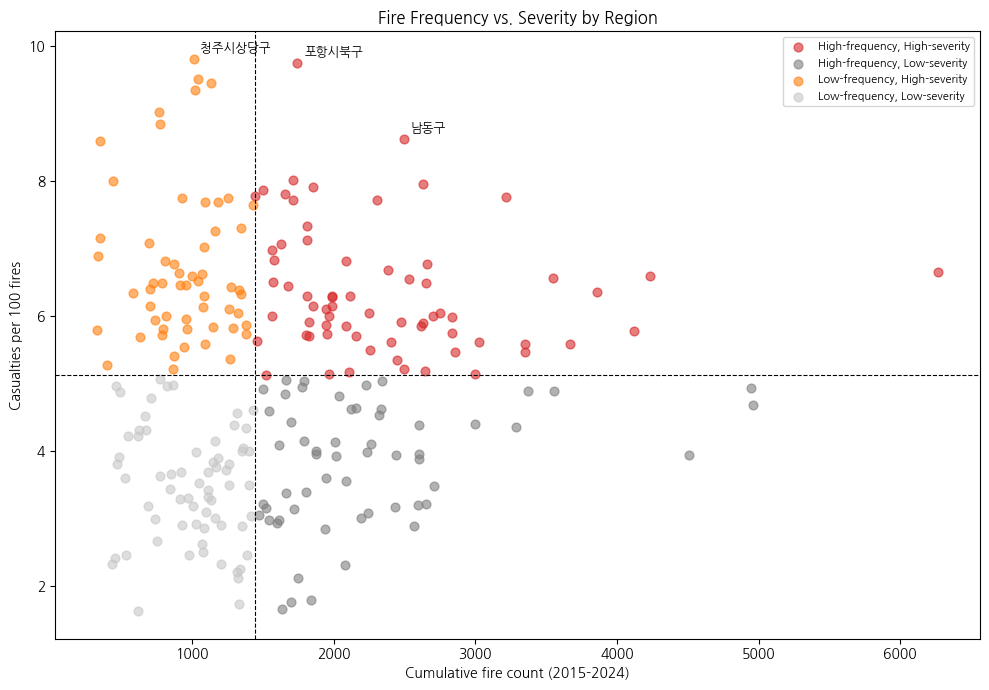

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'High-frequency, High-severity': '#d62728',
          'High-frequency, Low-severity': '#7f7f7f',
          'Low-frequency, High-severity': '#ff7f0e',
          'Low-frequency, Low-severity': '#c7c7c7'}

for q, group in region_main.groupby('quadrant'):
    ax.scatter(group['화재건수'], group['casualties_per_100_excl'],
               c=colors[q], label=q, alpha=0.6, s=40)

ax.axvline(count_median, color='black', linestyle='--', linewidth=0.8)
ax.axhline(severity_median, color='black', linestyle='--', linewidth=0.8)

# Label the key regions found in this analysis
highlight = [('충청북도','청주시상당구'), ('인천광역시','남동구'), ('경상북도','포항시북구')]
for sido, sigungu in highlight:
    row = region_main[(region_main['시도']==sido)&(region_main['시군구']==sigungu)]
    if len(row):
        ax.annotate(sigungu, (row['화재건수'].values[0], row['casualties_per_100_excl'].values[0]),
                    textcoords="offset points", xytext=(5,5), fontsize=9, fontweight='bold')

ax.set_xlabel('Cumulative fire count (2015-2024)')
ax.set_ylabel('Casualties per 100 fires')
ax.set_title('Fire Frequency vs. Severity by Region')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fire_data/processed/frequency_vs_severity_scatter.png', dpi=150)
plt.show()

from google.colab import files
files.download('/content/drive/MyDrive/fire_data/processed/frequency_vs_severity_scatter.png')

Note: 청주시상당구 sits in the "hidden" low-frequency/high-severity
quadrant. 남동구 and 포항시북구, despite having high absolute fire
counts, are flagged instead by a *different* test — their casualty
rate exceeds what their place-type composition alone would predict
(see 05_excess_risk_analysis.ipynb). Both are forms of the same
underlying problem: frequency-based prioritization alone misses them.